<a href="https://colab.research.google.com/github/StarGod-b/DataMining-SalesFootwear/blob/main/Collection_%26_Exploratory_Data_ENG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Data Collection & Exploratory Data**

---
### DATA COLLECTION
---

Mounted at /content/drive


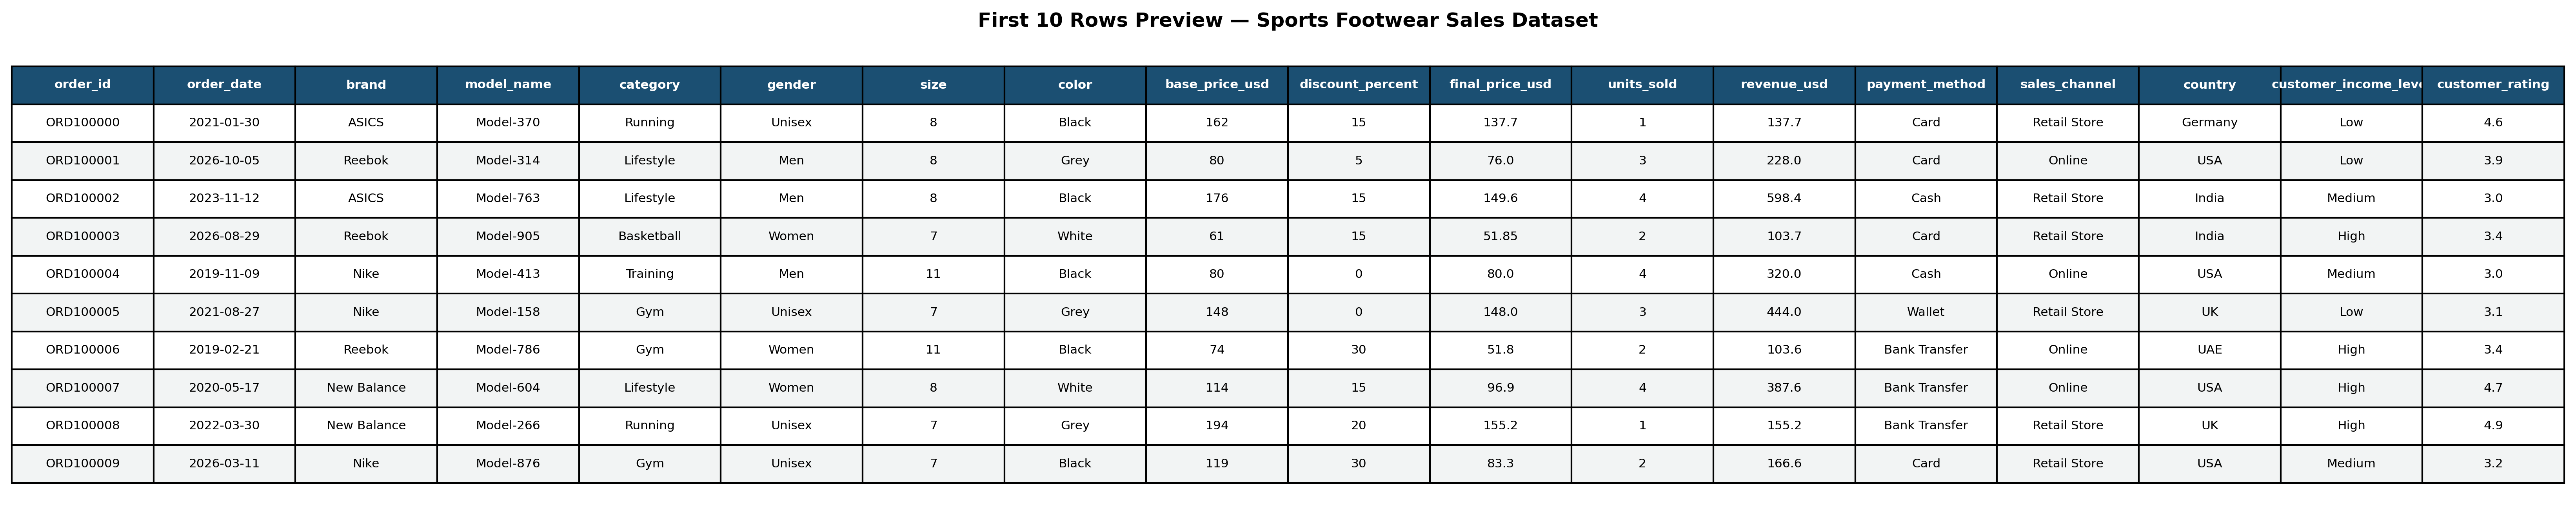

[✔] First 10 rows table displayed successfully.


In [ ]:
# =============================================================
# DATA COLLECTION: Import Library & Load Dataset
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 10,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'figure.dpi'      : 300,
    'axes.grid'       : True,
    'grid.alpha'      : 0.35,
    'grid.linestyle'  : '--',
})

from google.colab import drive
drive.mount('/content/drive')
PATH = '/content/drive/MyDrive/Colab Notebooks/DWDM/global_sports_footwear_sales_2018_2026.csv'
df = pd.read_csv(PATH)

# ── Display first 10 rows ───────────────────────────────────
df_sample = df.head(10).copy()
fig_head, ax_head = plt.subplots(figsize=(22, 4.5))   # ← taller for 10 rows
ax_head.axis('off')

table = ax_head.table(
    cellText   = df_sample.values.tolist(),
    colLabels  = df_sample.columns.tolist(),
    cellLoc    = 'center',
    loc        = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(7.5)
table.scale(1, 1.7)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1B4F72')
        cell.set_text_props(color='white', weight='bold')
    else:
        cell.set_facecolor('#F2F4F4' if row % 2 == 0 else 'white')

plt.title('First 10 Rows Preview — Sports Footwear Sales Dataset',
          fontweight='bold', fontsize=12, pad=10)
plt.tight_layout()
plt.show()
print('[✔] First 10 rows table displayed successfully.')

			DATA STRUCTURE INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30000 non-null  object 
 1   order_date             30000 non-null  object 
 2   brand                  30000 non-null  object 
 3   model_name             30000 non-null  object 
 4   category               30000 non-null  object 
 5   gender                 30000 non-null  object 
 6   size                   30000 non-null  int64  
 7   color                  30000 non-null  object 
 8   base_price_usd         30000 non-null  int64  
 9   discount_percent       30000 non-null  int64  
 10  final_price_usd        30000 non-null  float64
 11  units_sold             30000 non-null  int64  
 12  revenue_usd            30000 non-null  float64
 13  payment_method         30000 non-null  object 
 14  sales_channel          3

Text(0.5, 1.0, '\nData Integrity Report — 30,000 rows | 18 columns | Duplicates: 0')

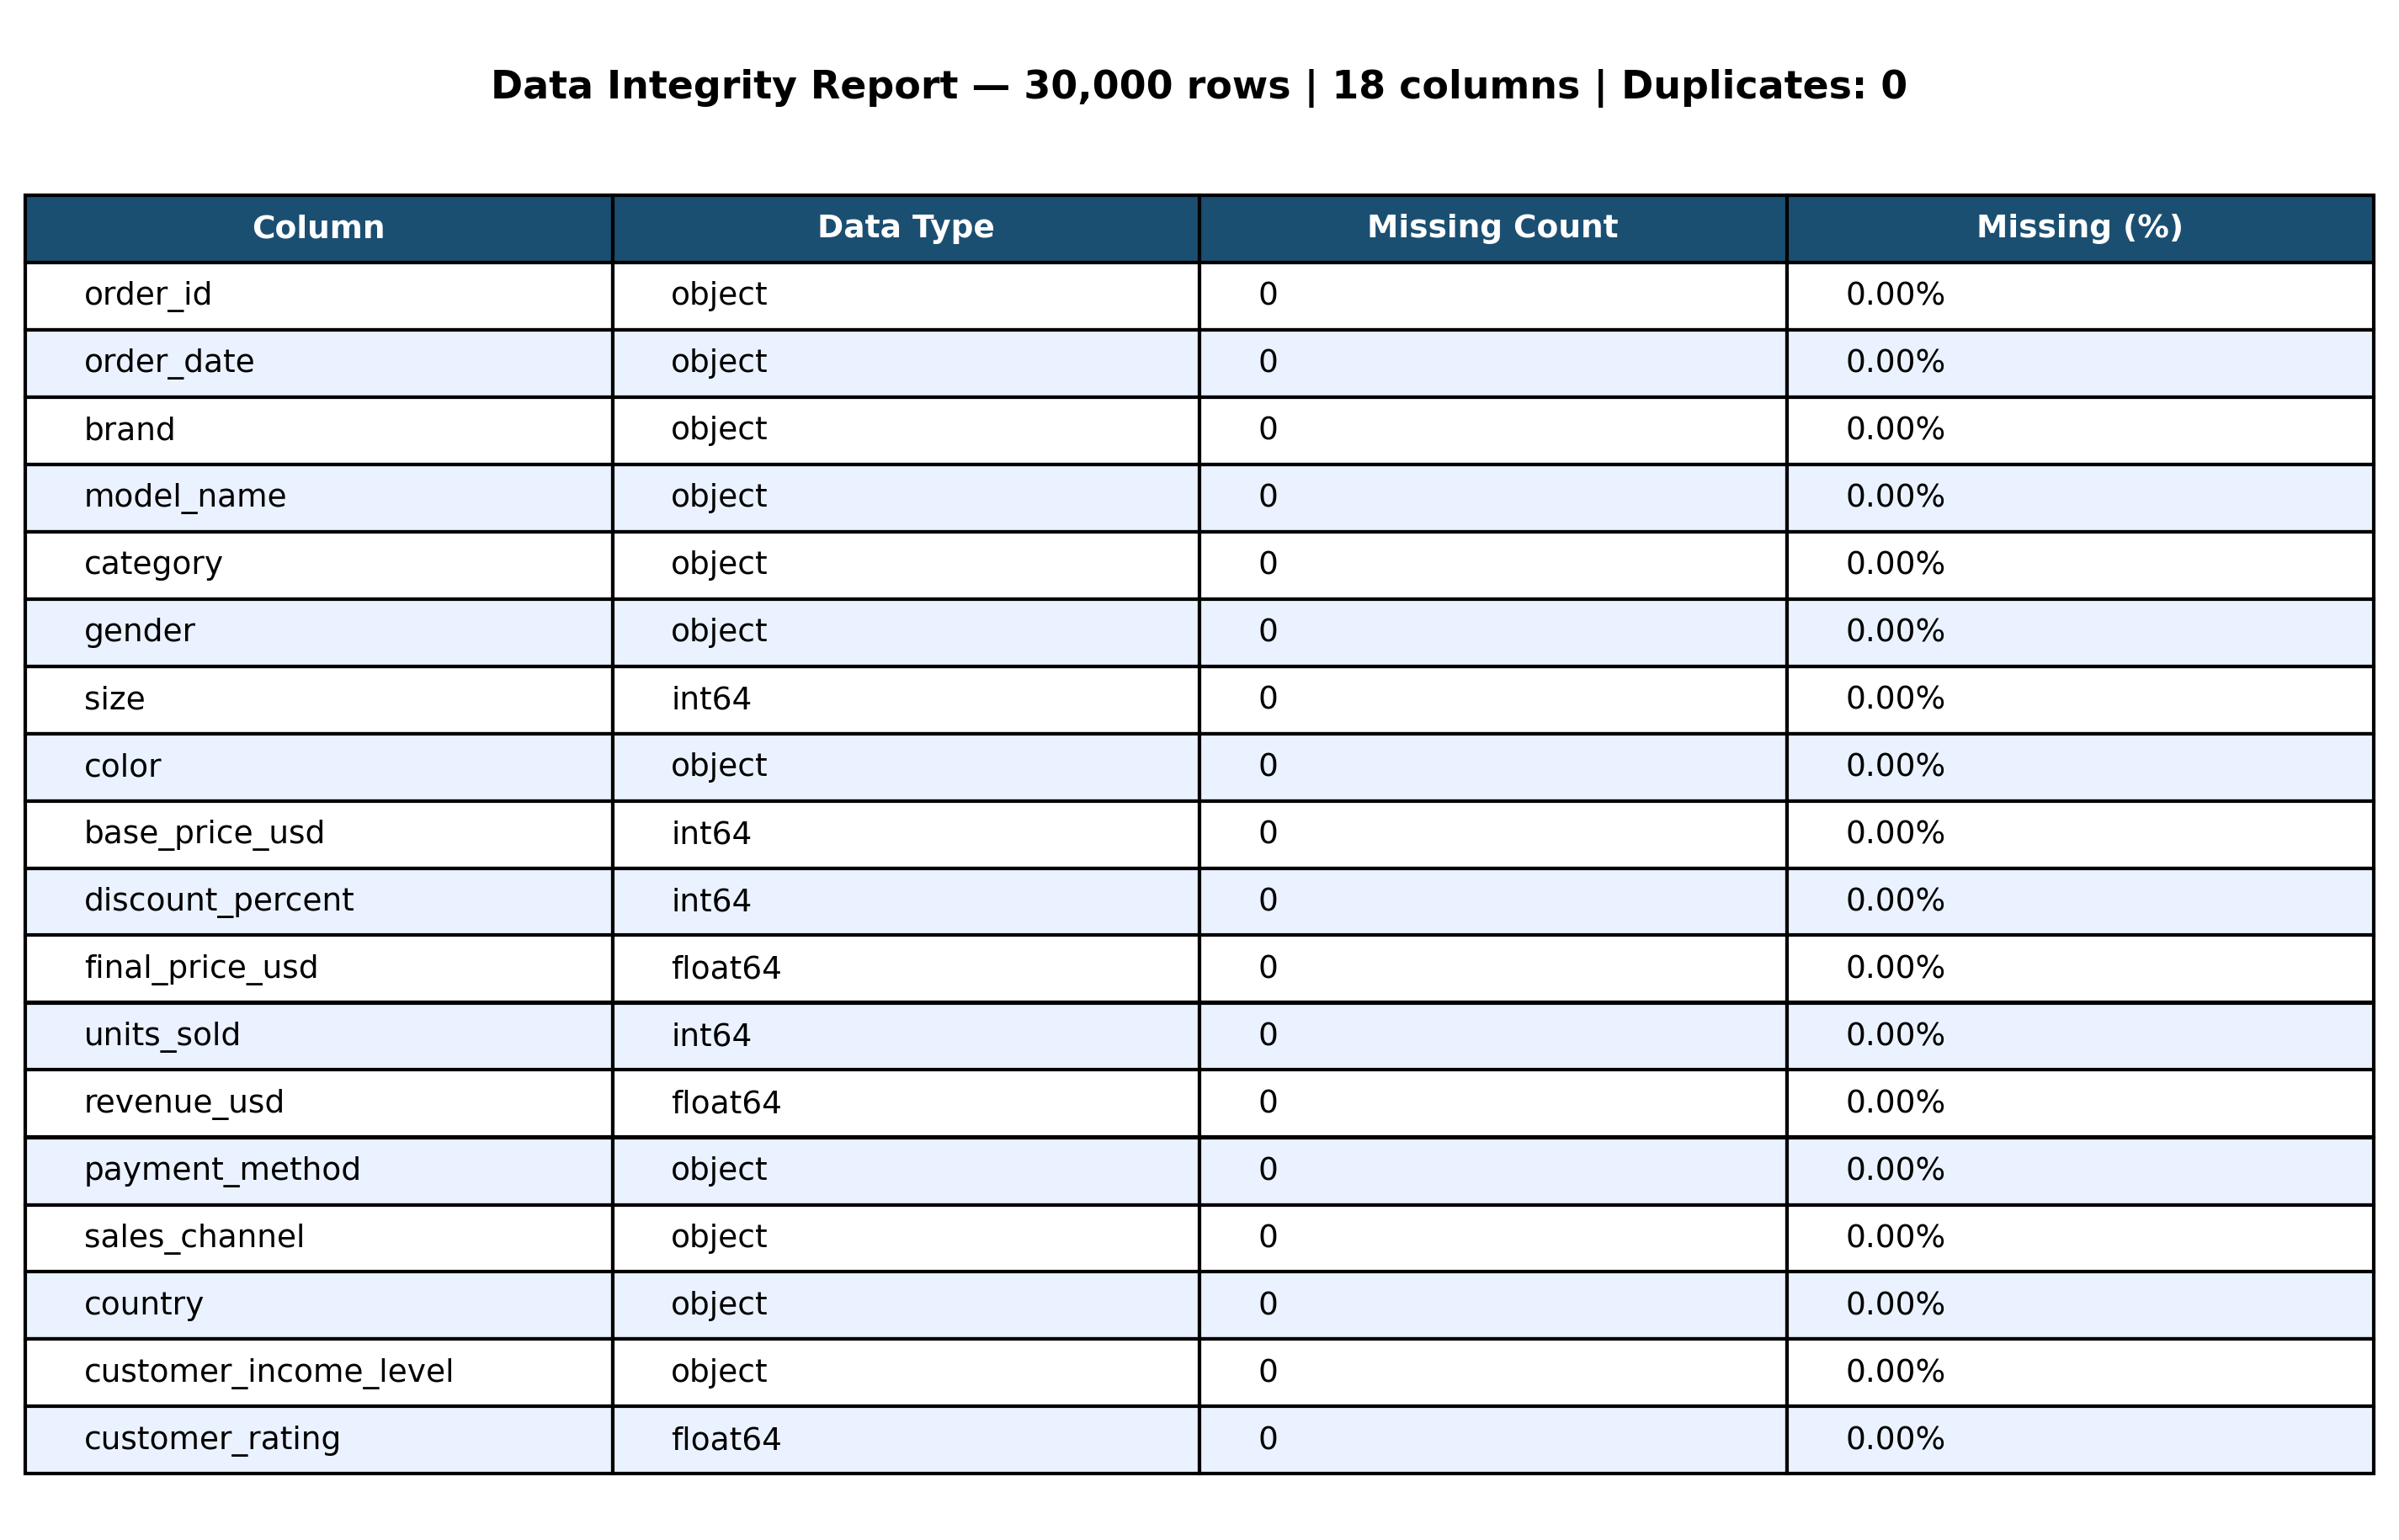

In [ ]:
# =============================================================
# DATA COLLECTION: Data Structure & Quality Information
# =============================================================
print('=' * 55)
print('\t\t\tDATA STRUCTURE INFORMATION')
print('=' * 55)
df.info()

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)


print('\n' + '=' * 55)
print('\t\t\tDUPLICATE DATA CHECK')
print('=' * 55)
n_dup = df.duplicated().sum()
print(f'Number of duplicate rows : {n_dup}')
print(f'Total dataset rows       : {len(df):,}')
print(f'Total dataset columns    : {df.shape[1]}')

# Visualisasi Laporan Integritas Data
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

col_labels = ['Column', 'Data Type', 'Missing Count', 'Missing (%)']
rows_data  = [
    [col, str(dtype), str(int(missing[col])), f'{missing_pct[col]:.2f}%']
    for col, dtype in zip(df.columns, df.dtypes)
]

tbl = ax.table(cellText=rows_data, colLabels=col_labels, cellLoc='left', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.6)

for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#1B4F72')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
for i in range(1, len(rows_data)+1):
    for j in range(len(col_labels)):
        if i % 2 == 0:
            tbl[(i, j)].set_facecolor('#EAF2FF')

ax.set_title(
    f'\nData Integrity Report — {len(df):,} rows | {df.shape[1]} columns | Duplicates: {n_dup}',
    fontsize=11, fontweight='bold', pad=16
)

---
### EDA ASSOCIATION
---

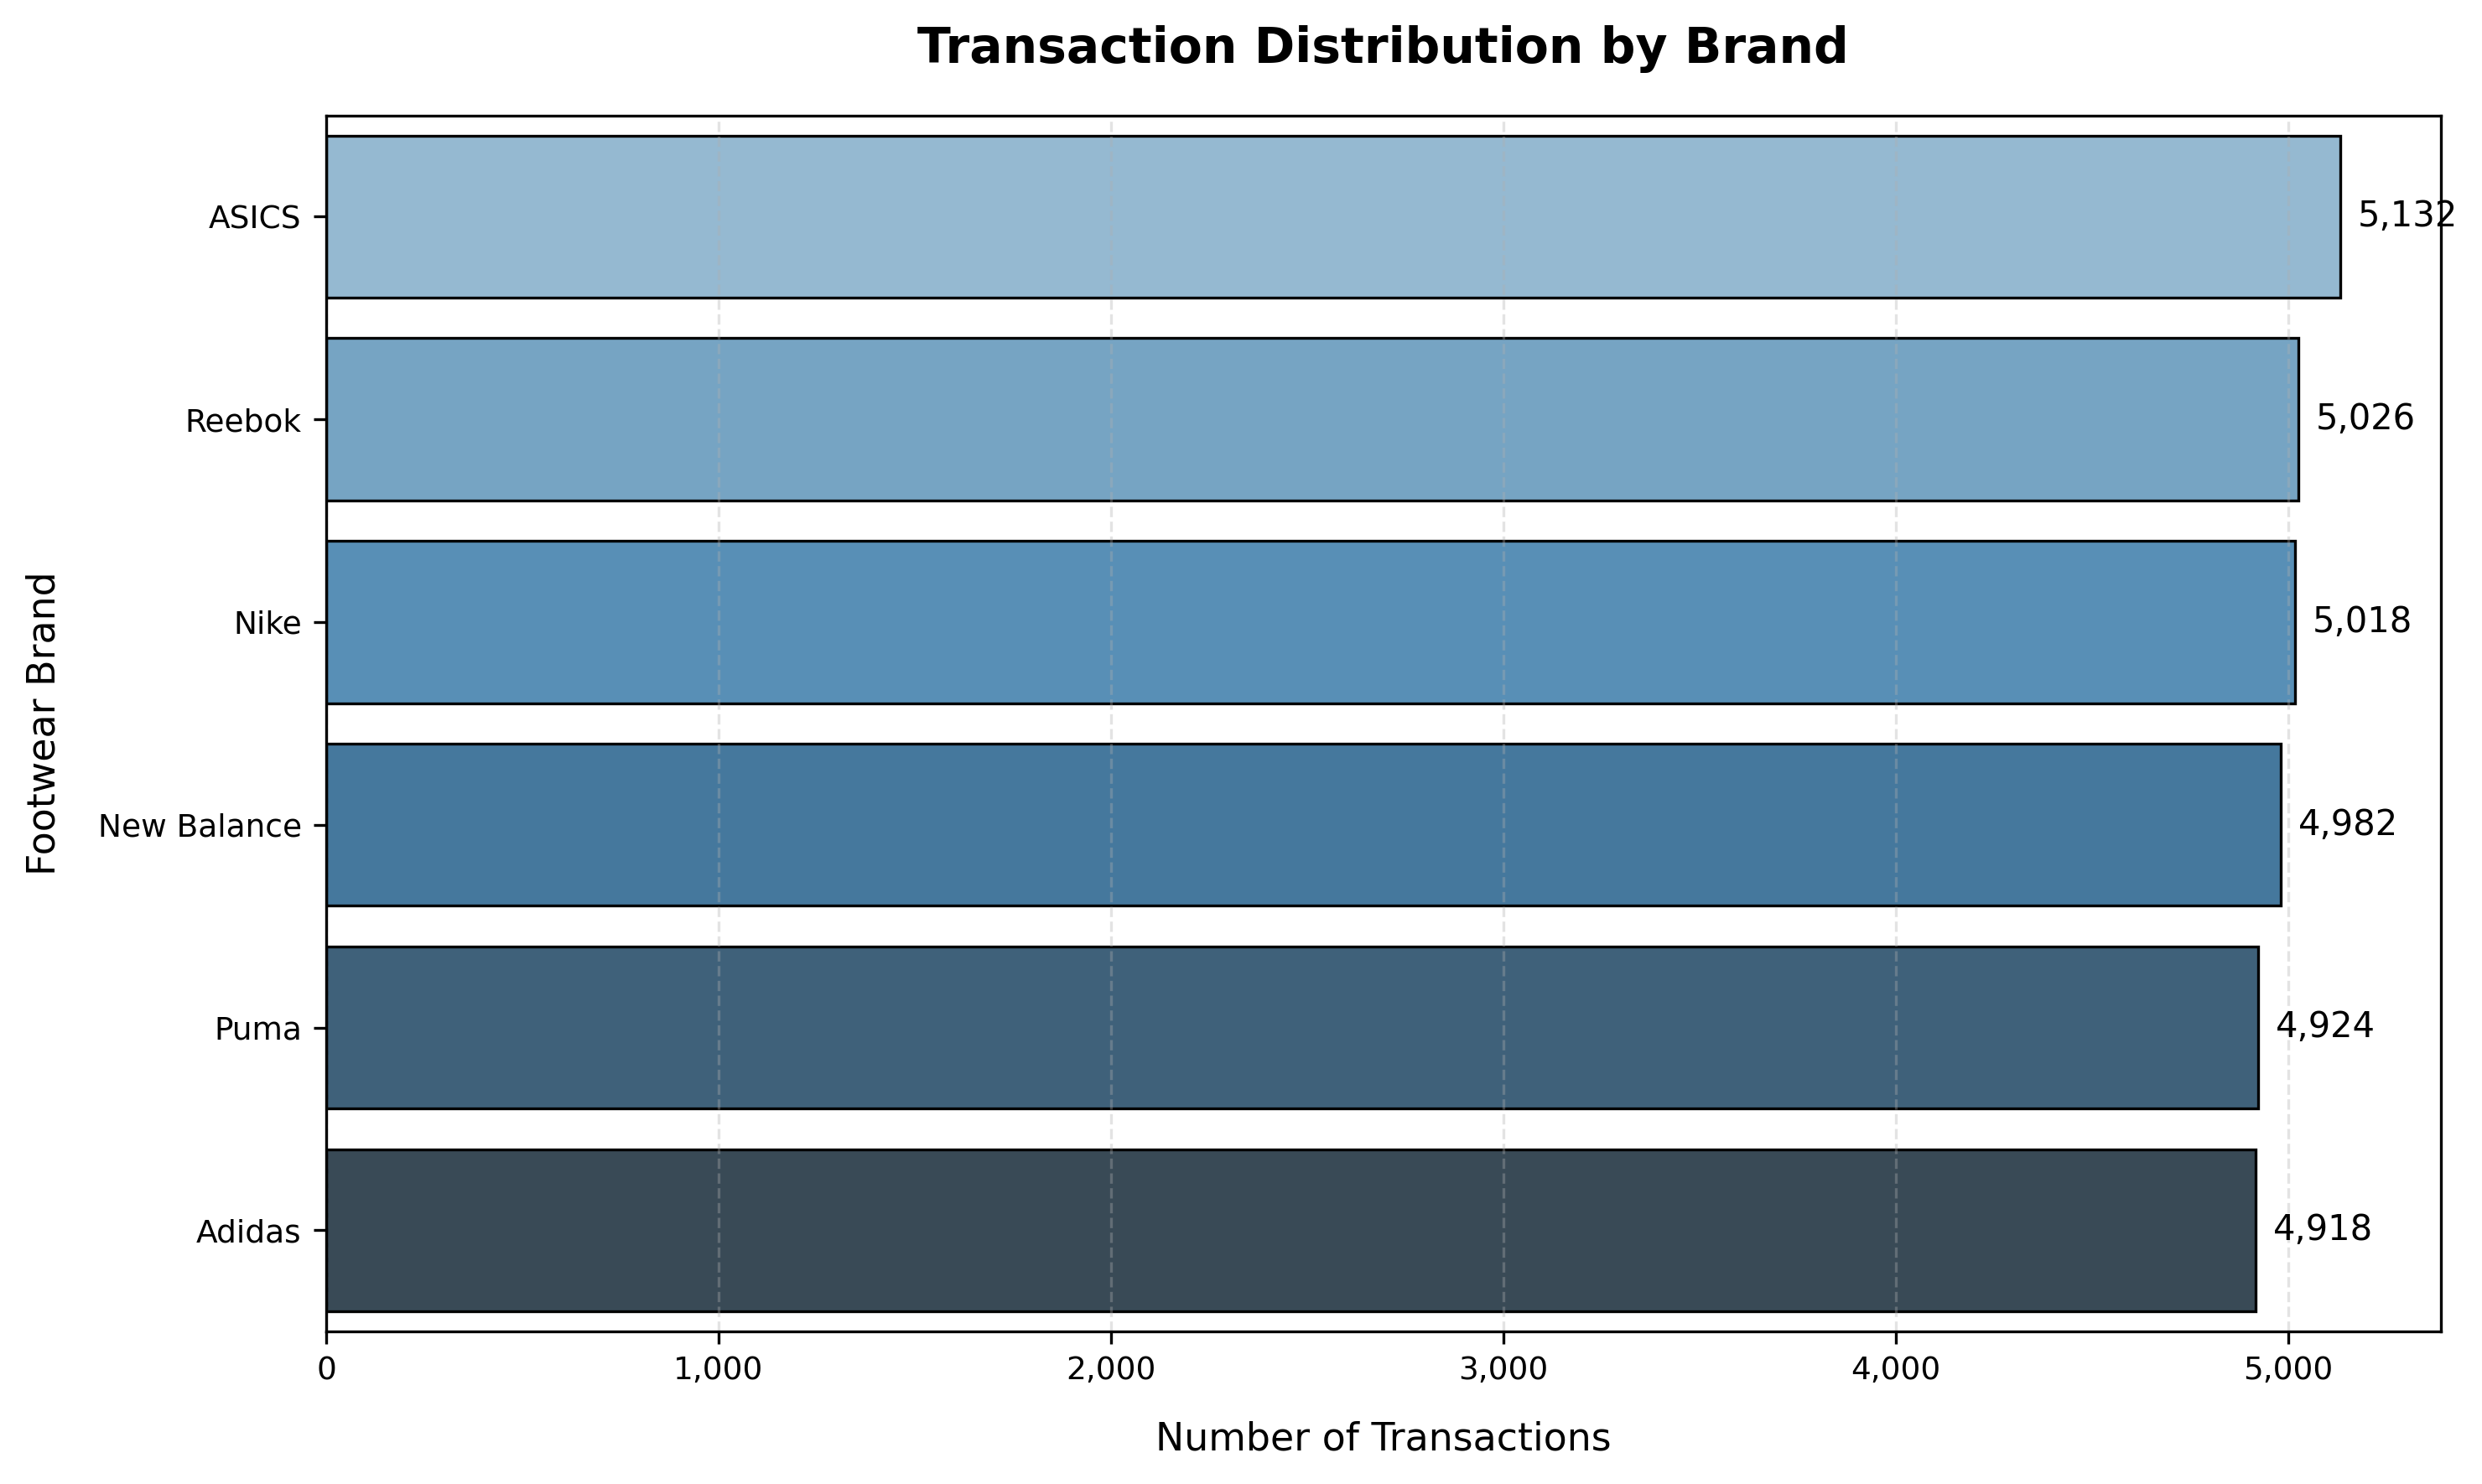

In [ ]:
# =============================================================
# EDA ASSOCIATION
# Brand & Category Distribution (item frequency for Apriori)
# =============================================================

# -- High-contrast academic palette --
PAL_BRAND = sns.color_palette('Blues_d', n_colors=df['brand'].nunique())
PAL_CAT   = sns.color_palette('dark:#5A9_r', n_colors=df['category'].nunique())

brand_order = df['brand'].value_counts().index
cat_order   = df['category'].value_counts().index

# --- FIGURE 1: Brand Distribution ---
fig1, ax1 = plt.subplots(figsize=(10, 6))
bars1 = sns.countplot(
    data=df, y='brand', order=brand_order,
    palette=PAL_BRAND, ax=ax1, edgecolor='black', linewidth=0.8
)
ax1.set_title('Transaction Distribution by Brand', fontweight='bold', fontsize=14, pad=15)
ax1.set_xlabel('Number of Transactions', labelpad=10, fontsize=11)
ax1.set_ylabel('Footwear Brand', labelpad=10, fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotate bar values
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_width()):,}',
                 (p.get_width(), p.get_y() + p.get_height() / 2),
                 ha='left', va='center', fontsize=10, color='black',
                 xytext=(5, 0), textcoords='offset points', fontweight='medium')

plt.tight_layout()
plt.savefig('gambar_4_X1_eda_brand.png', dpi=300, bbox_inches='tight')
plt.show()

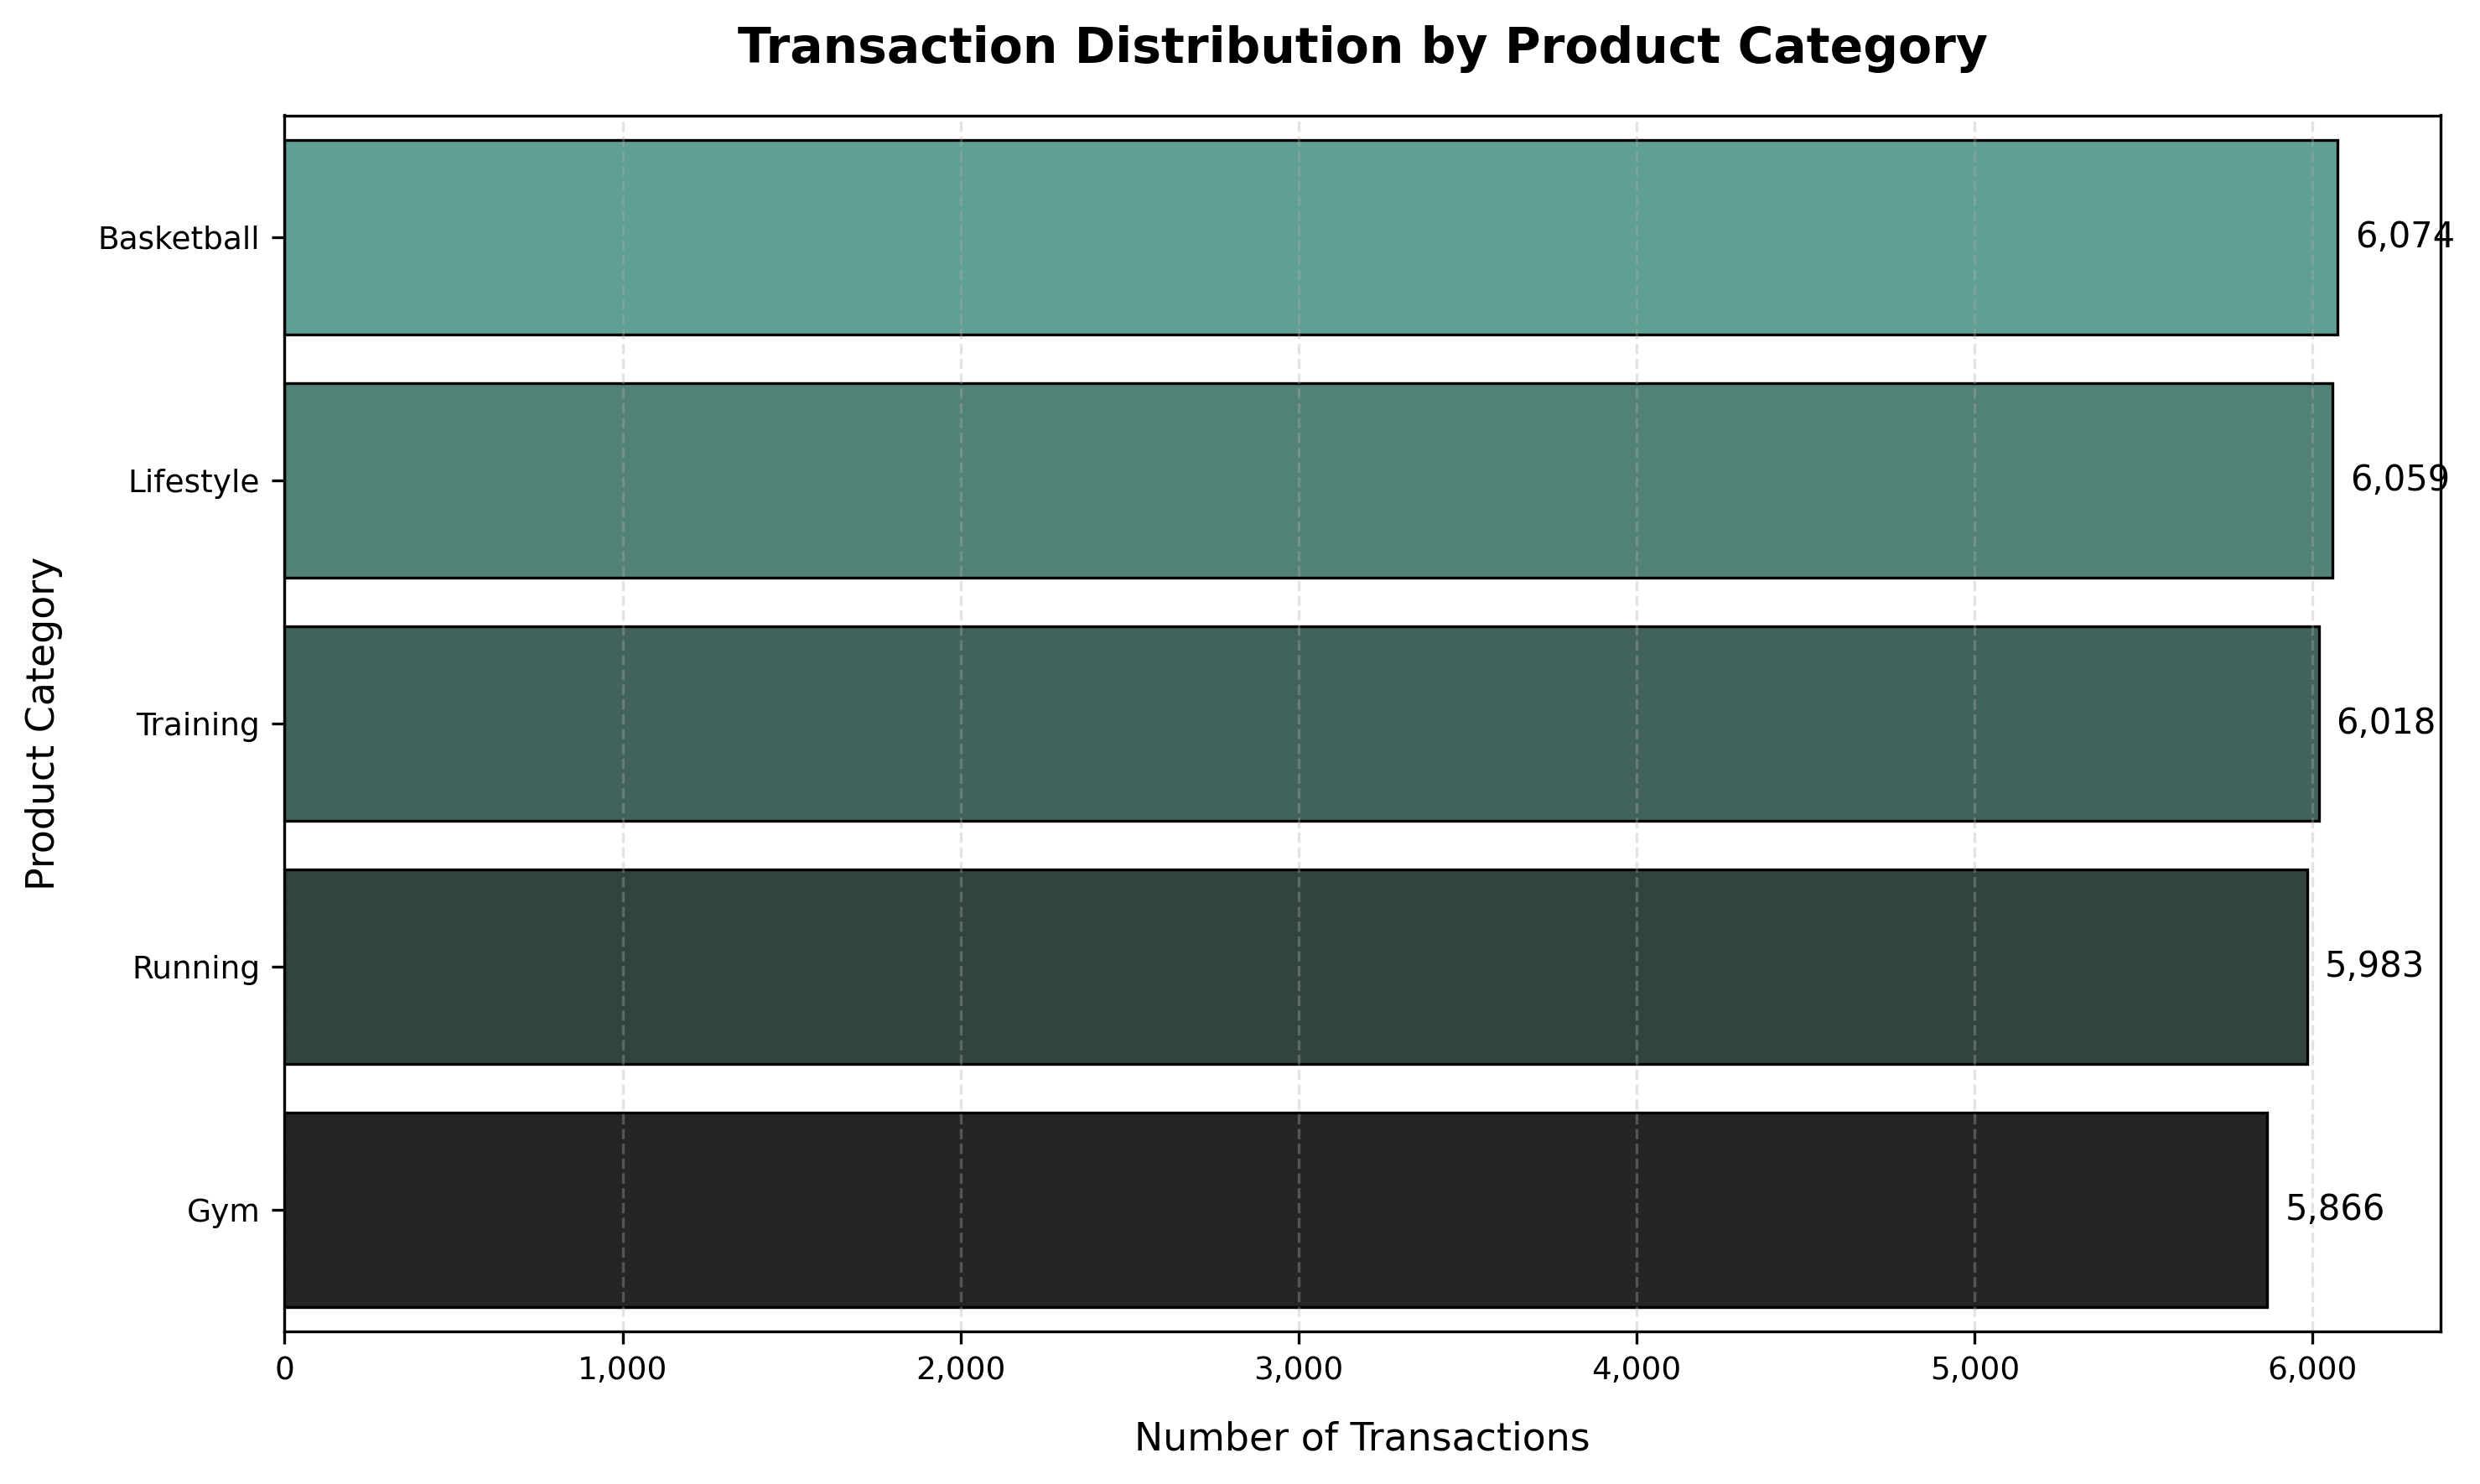


--- Brand Distribution Summary ---


,Brand,Frequency
0,ASICS,5132
1,Reebok,5026
2,Nike,5018
3,New Balance,4982
4,Puma,4924
5,Adidas,4918



--- Category Distribution Summary ---


,Category,Frequency
0,Basketball,6074
1,Lifestyle,6059
2,Training,6018
3,Running,5983
4,Gym,5866


In [ ]:
# --- FIGURE 2: Category Distribution ---
fig2, ax2 = plt.subplots(figsize=(10, 6)) # Single large figure
bars2 = sns.countplot(
    data=df, y='category', order=cat_order,
    palette=PAL_CAT, ax=ax2, edgecolor='black', linewidth=0.8
)
ax2.set_title('Transaction Distribution by Product Category', fontweight='bold', fontsize=14, pad=15)
ax2.set_xlabel('Number of Transactions', labelpad=10, fontsize=11)
ax2.set_ylabel('Product Category', labelpad=10, fontsize=11)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width()):,}',
                 (p.get_width(), p.get_y() + p.get_height() / 2),
                 ha='left', va='center', fontsize=10, color='black',
                 xytext=(5, 0), textcoords='offset points', fontweight='medium')

plt.tight_layout()
plt.savefig('gambar_4_X2_eda_category.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n--- Brand Distribution Summary ---')
display(df['brand'].value_counts().rename_axis('Brand').reset_index(name='Frequency'))
print('\n--- Category Distribution Summary ---')
display(df['category'].value_counts().rename_axis('Category').reset_index(name='Frequency'))

---
### EDA CLASSIFICATION
---

In [ ]:
# =====================================================================
# EDA CLASSIFICATION — UNIVARIATE DATA PREPARATION
# =====================================================================
PALETTE_TARGET = {'Low': '#27AE60', 'Medium': '#2980B9', 'High': '#C0392B'}

income_counts = df['customer_income_level'].value_counts().reindex(['Low', 'Medium', 'High'])
income_pct    = income_counts / income_counts.sum() * 100
colors        = [PALETTE_TARGET[c] for c in income_counts.index]

print("=== Customer Income Level Distribution ===")
for cls, cnt, pct in zip(income_counts.index, income_counts, income_pct):
    print(f"  {cls:8s} : {cnt:,} records ({pct:.2f}%)")
print(f"\n  Total    : {income_counts.sum():,} records")

=== Customer Income Level Distribution ===
  Low      : 9,944 records (33.15%)
  Medium   : 9,997 records (33.32%)
  High     : 10,059 records (33.53%)

  Total    : 30,000 records


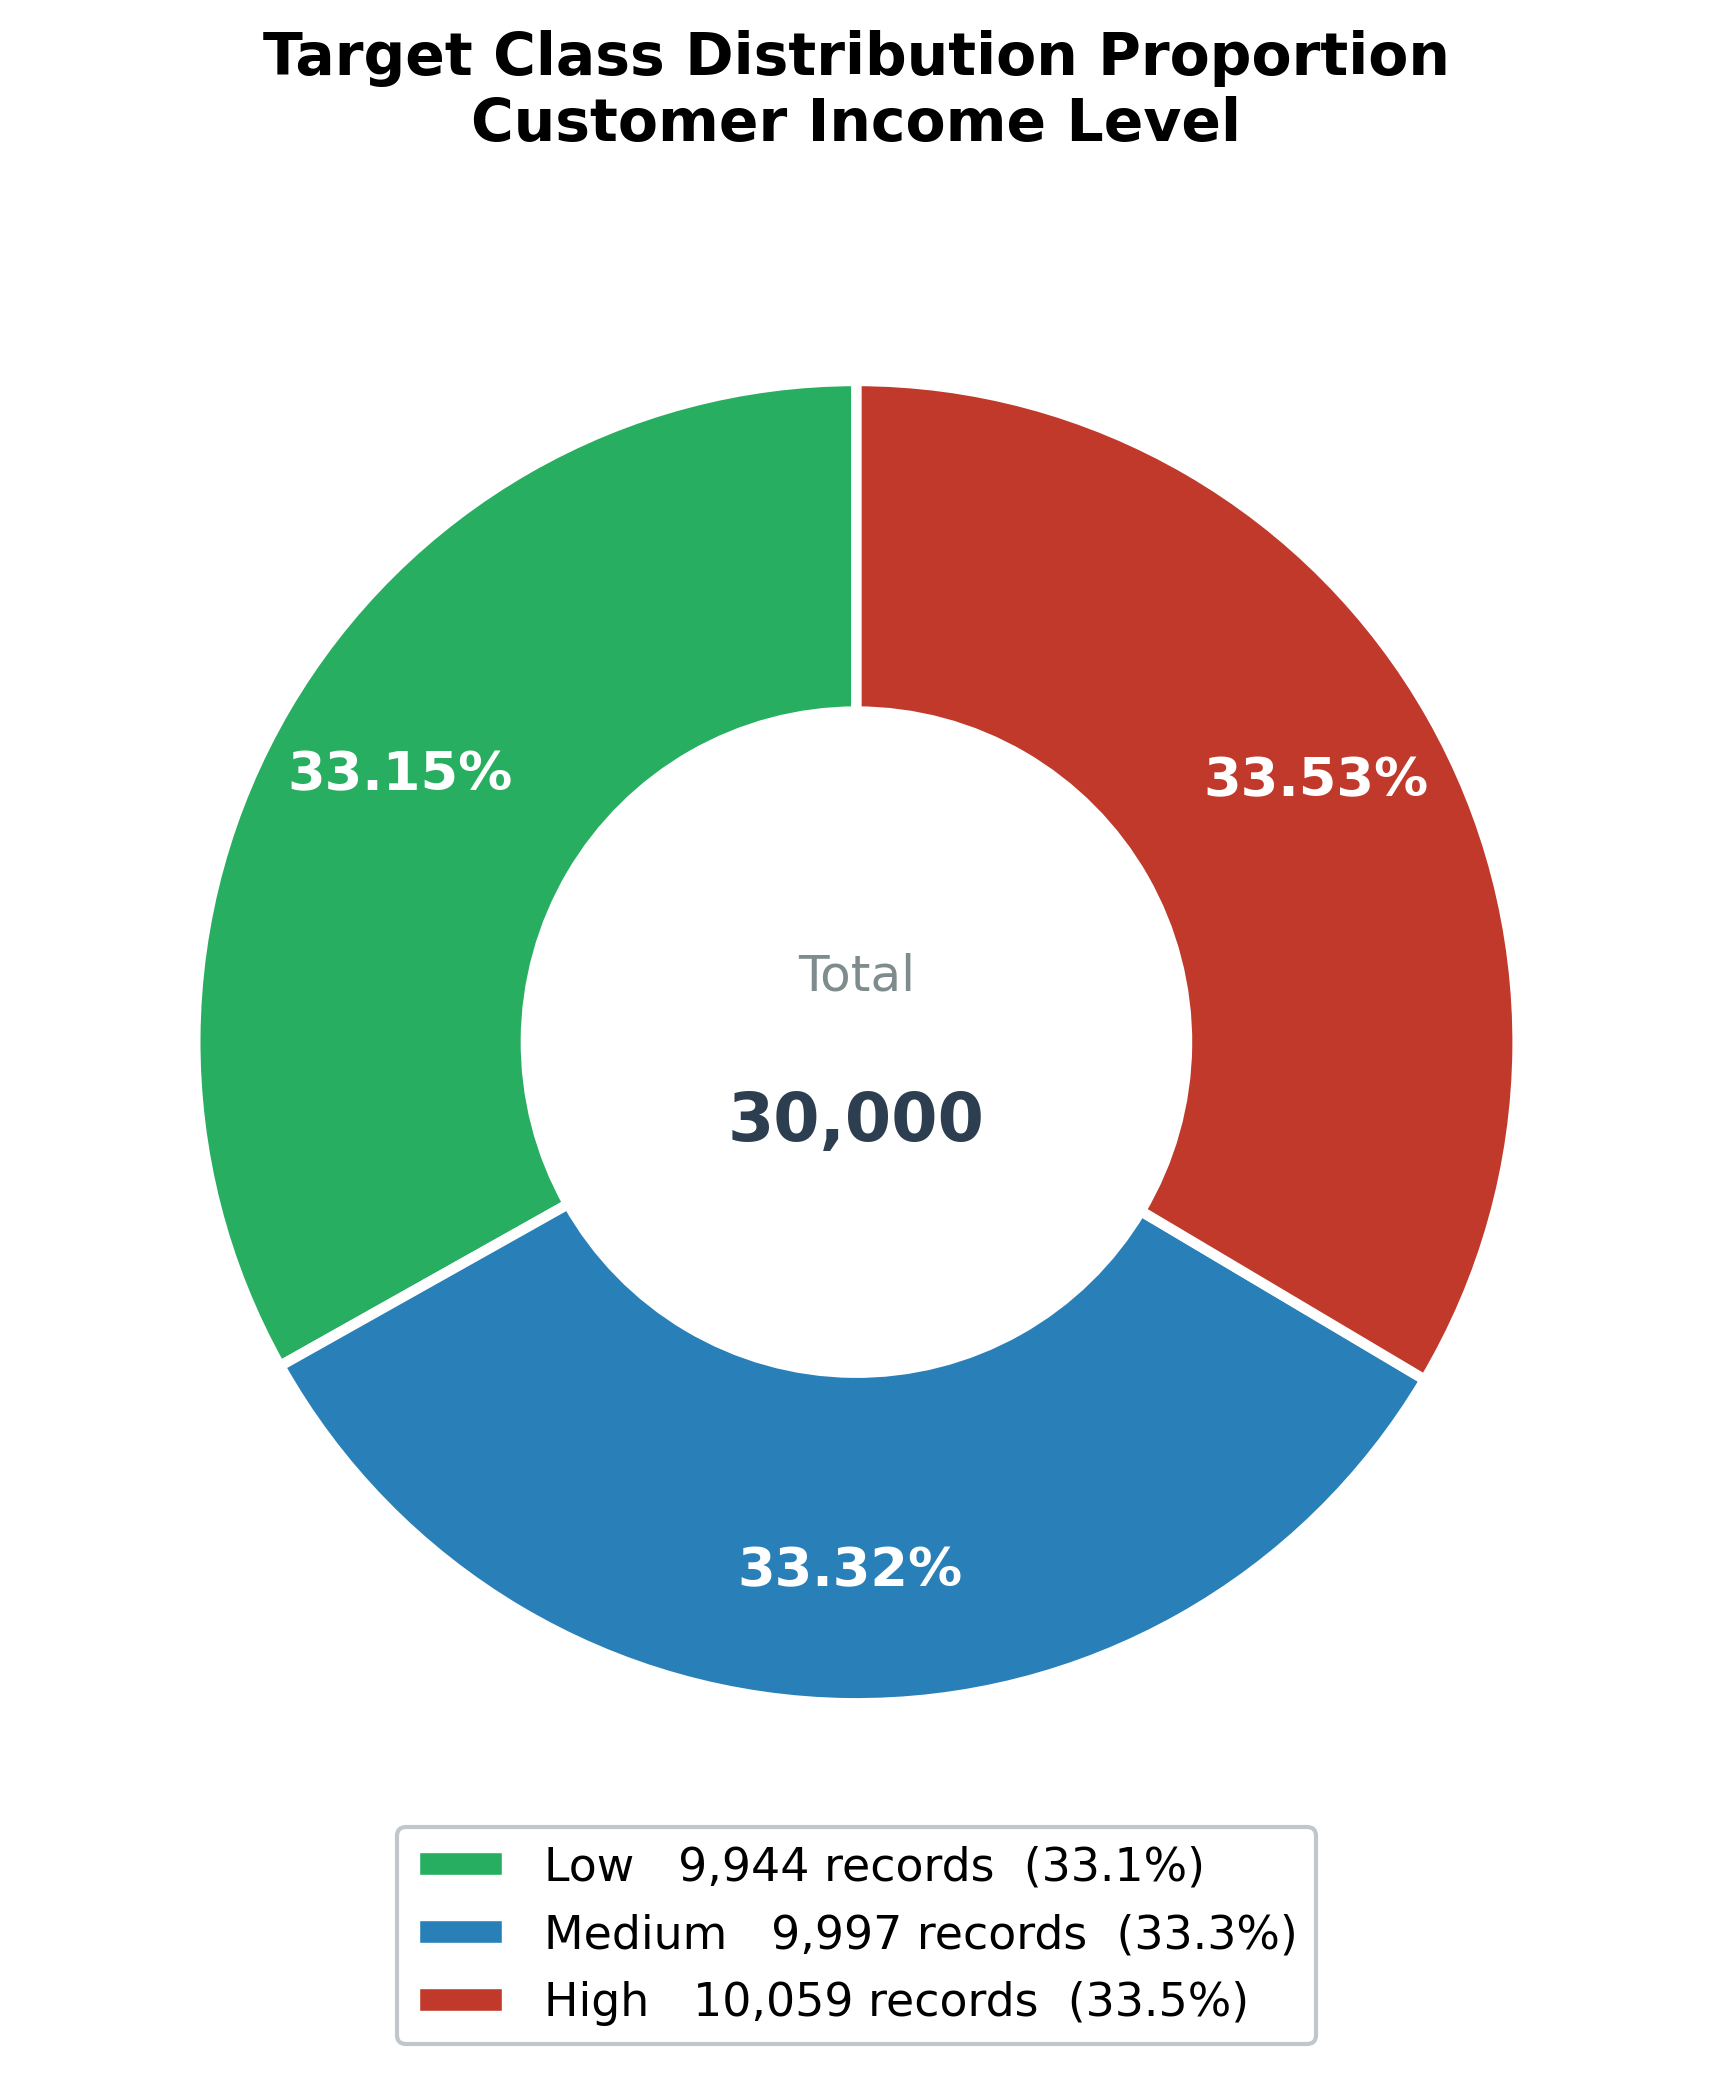

In [ ]:
# =====================================================================
# EDA CLASSIFICATION — DONUT CHART
# =====================================================================
fig, ax1 = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('white')

wedges, _, autotexts = ax1.pie(
    income_counts, colors=colors, autopct='%1.2f%%',
    startangle=90, pctdistance=0.80,
    wedgeprops=dict(width=0.50, edgecolor='white', linewidth=2.5)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

# Label di tengah donut
ax1.text(0, 0.10, 'Total', ha='center', va='center',
         fontsize=12, color='#7F8C8D')
ax1.text(0, -0.12, f'{income_counts.sum():,}', ha='center', va='center',
         fontsize=16, fontweight='bold', color='#2C3E50')

legend_labels = [f"{lbl}   {cnt:,} records  ({pct:.1f}%)"
                 for lbl, cnt, pct in zip(income_counts.index, income_counts, income_pct)]
ax1.legend(wedges, legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.12),
           ncol=1, fontsize=11, frameon=True,
           facecolor='white', framealpha=0.95, edgecolor='#BDC3C7')

ax1.set_title('Target Class Distribution Proportion\nCustomer Income Level',
              fontweight='bold', fontsize=14, pad=18)

plt.tight_layout()
plt.savefig('gambar_eda_donut_income.png', dpi=300, bbox_inches='tight')
plt.show()

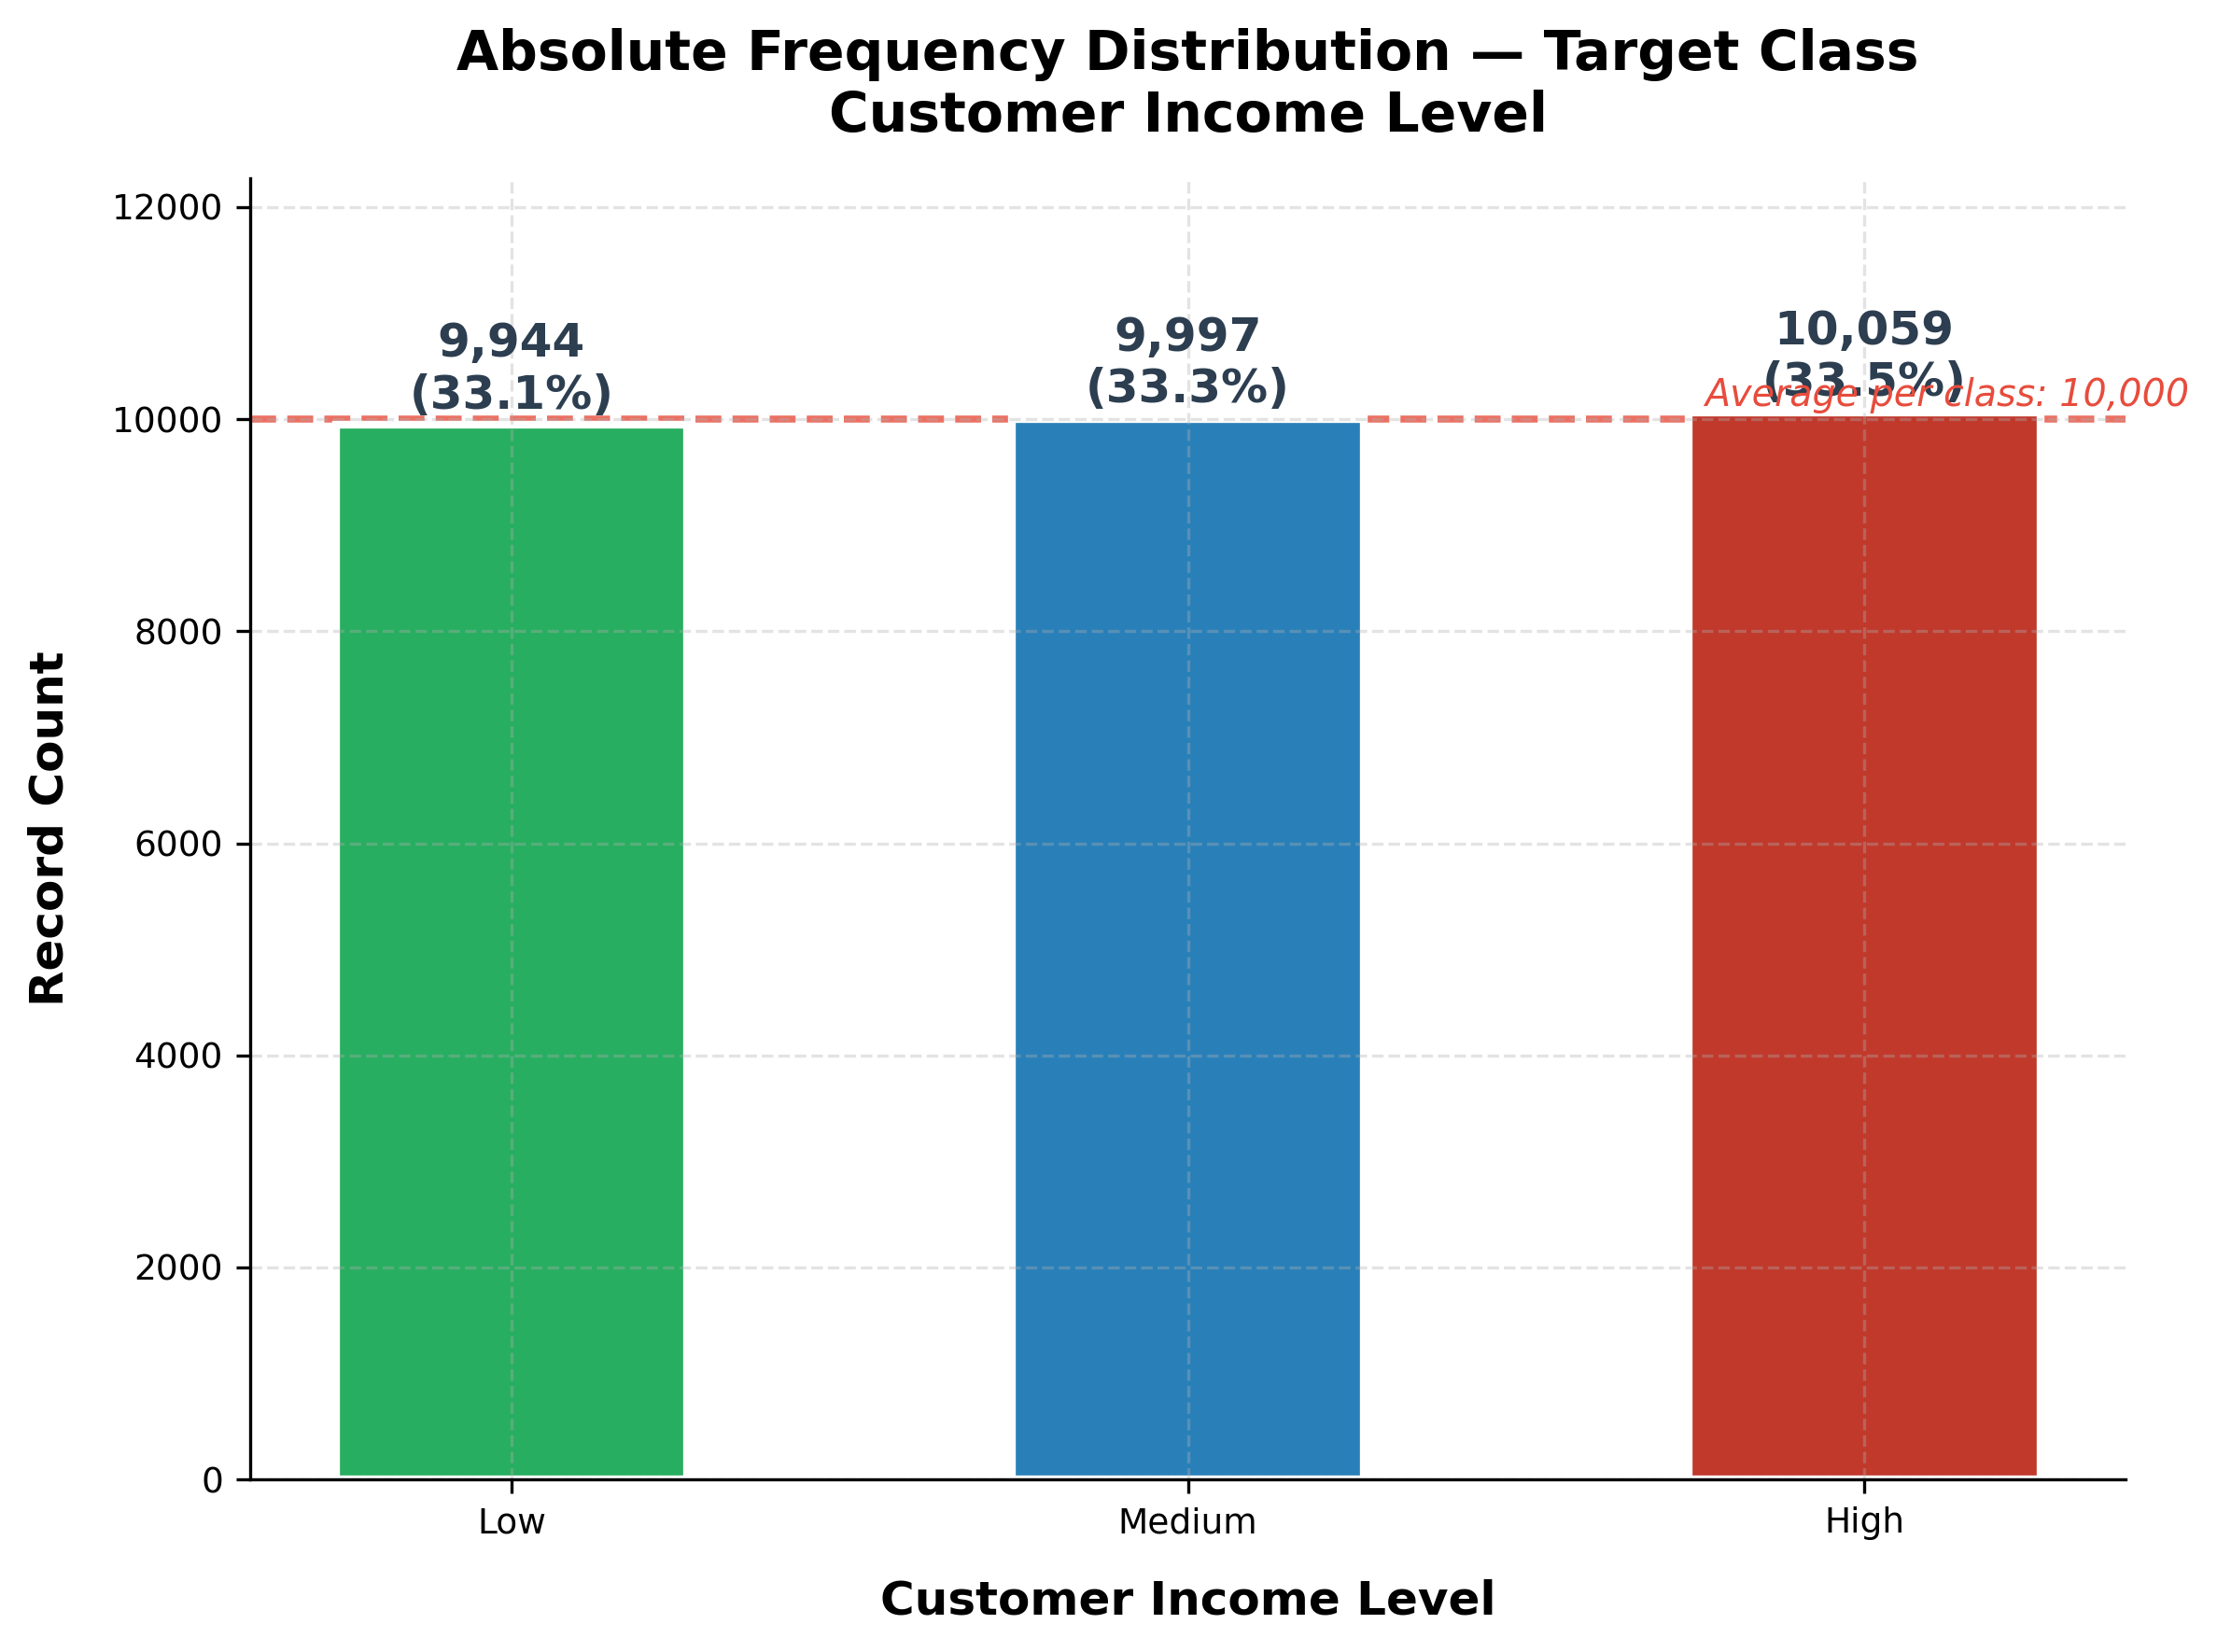

In [ ]:
# =====================================================================
# EDA CLASSIFICATION — ANNOTATED BAR CHART
# =====================================================================
fig, ax2 = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')

bars = ax2.bar(income_counts.index, income_counts.values,
               color=colors, edgecolor='white', linewidth=2.0, width=0.52)

for bar, cnt, pct in zip(bars, income_counts.values, income_pct):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 70,
             f'{cnt:,}\n({pct:.1f}%)',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold', color='#2C3E50')

# Average line
mean_val = income_counts.mean()
ax2.axhline(mean_val, color='#E74C3C', linewidth=1.8,
            linestyle='--', alpha=0.80, zorder=0)
ax2.text(2.48, mean_val + 55,
         f'Average per class: {mean_val:,.0f}',
         ha='right', va='bottom', fontsize=9.5,
         color='#E74C3C', style='italic')

ax2.set_ylim(0, income_counts.max() * 1.22)
ax2.set_xlabel('Customer Income Level', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_ylabel('Record Count', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_title('Absolute Frequency Distribution — Target Class\nCustomer Income Level',
              fontweight='bold', fontsize=14, pad=12)
ax2.grid(True, axis='y', linestyle='--', alpha=0.35, zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('gambar_eda_bar_income.png', dpi=300, bbox_inches='tight')
plt.show()

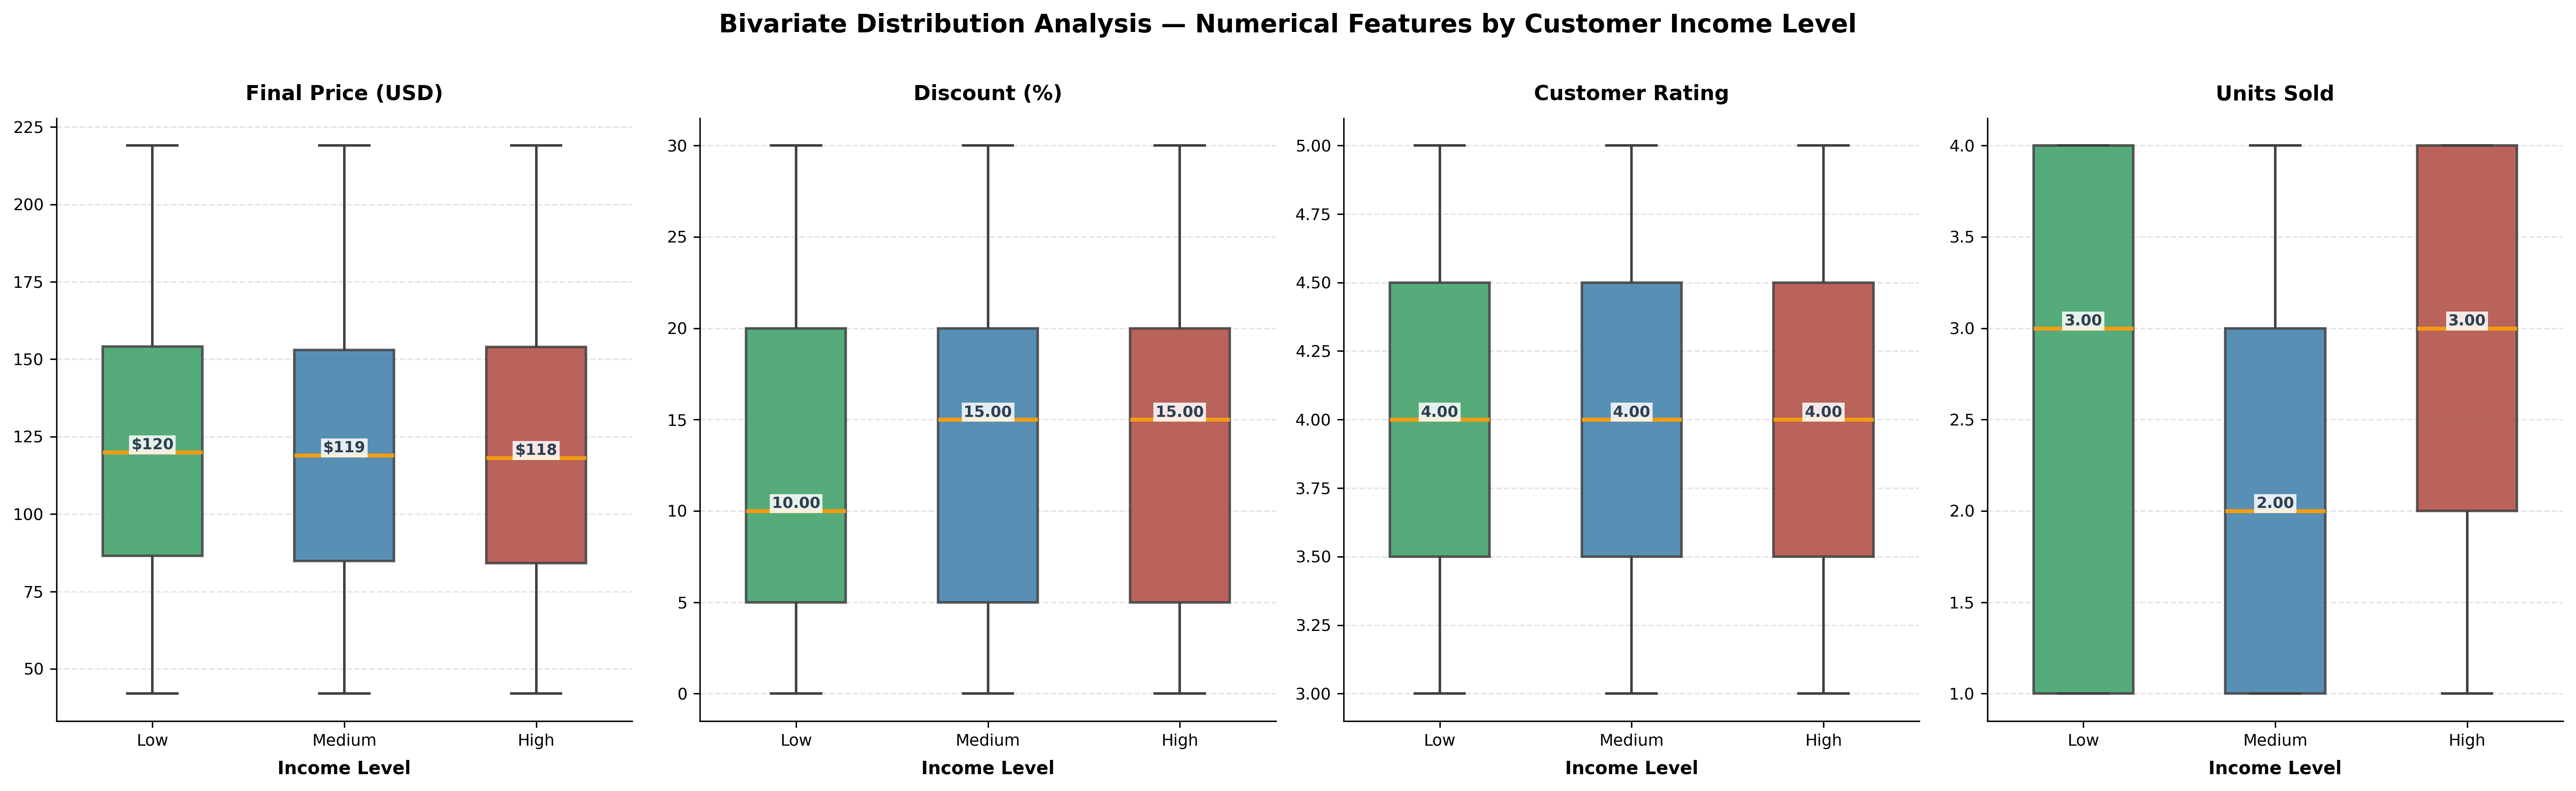

=== BIVARIATE STATISTICS SUMMARY ===

final_price_usd:
                       median        mean        std
customer_income_level                               
Low                    120.00  121.855727  42.329444
Medium                 119.00  120.685156  42.315086
High                   118.15  120.553554  42.876767

discount_percent:
                       median       mean       std
customer_income_level                             
Low                      10.0  13.245676  9.756261
Medium                   15.0  13.399020  9.926457
High                     15.0  13.351228  9.908510

customer_rating:
                       median      mean       std
customer_income_level                            
Low                       4.0  4.000553  0.575320
Medium                    4.0  4.006962  0.580891
High                      4.0  3.997137  0.576421

units_sold:
                       median      mean       std
customer_income_level                            
Low                      

In [ ]:
# =====================================================================
# BIVARIATE EDA — NUMERICAL FEATURE DISTRIBUTION BY TARGET CLASS
# =====================================================================
NUMERIC_FEATURES = ['final_price_usd', 'discount_percent', 'customer_rating', 'units_sold']
INCOME_ORDER = ['Low', 'Medium', 'High']
PALETTE_INCOME = {'Low': '#27AE60', 'Medium': '#2980B9', 'High': '#C0392B'}

LABEL_MAP = {
    'final_price_usd': 'Final Price (USD)',
    'discount_percent': 'Discount (%)',
    'customer_rating': 'Customer Rating',
    'units_sold': 'Units Sold'
}

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Bivariate Distribution Analysis — Numerical Features by Customer Income Level',
             fontsize=14, fontweight='bold', y=1.01)

for ax, feat in zip(axes, NUMERIC_FEATURES):
    sns.boxplot(
        data=df, x='customer_income_level', y=feat,
        order=INCOME_ORDER, ax=ax, palette=PALETTE_INCOME,
        linewidth=1.4, fliersize=2.5, width=0.52,
        boxprops=dict(alpha=0.85), medianprops=dict(linewidth=2.2, color='#F39C12')
    )

    # Annotate median per class
    medians = df.groupby('customer_income_level')[feat].median().reindex(INCOME_ORDER)
    for i_box, (cls, med) in enumerate(medians.items()):
        fmt = f'${med:,.0f}' if feat == 'final_price_usd' else f'{med:.2f}'
        ax.text(i_box, med, fmt, ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='#2C3E50',
                bbox=dict(facecolor='white', edgecolor='none', pad=1.2, alpha=0.85))

    ax.set_title(LABEL_MAP[feat], fontweight='bold', fontsize=11.5, pad=10)
    ax.set_xlabel('Income Level', fontsize=10, fontweight='bold', labelpad=6)
    ax.set_ylabel('')
    ax.grid(True, axis='y', linestyle='--', alpha=0.35, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('gambar_eda_bivariat_income.png', dpi=300, bbox_inches='tight')
plt.show()

# Print ringkasan statistik untuk narasi
print("=== BIVARIATE STATISTICS SUMMARY ===")
for feat in NUMERIC_FEATURES:
    print(f"\n{feat}:")
    print(df.groupby('customer_income_level')[feat].agg(['median','mean','std']).reindex(INCOME_ORDER))

---
### EDA CLUSTERING
---

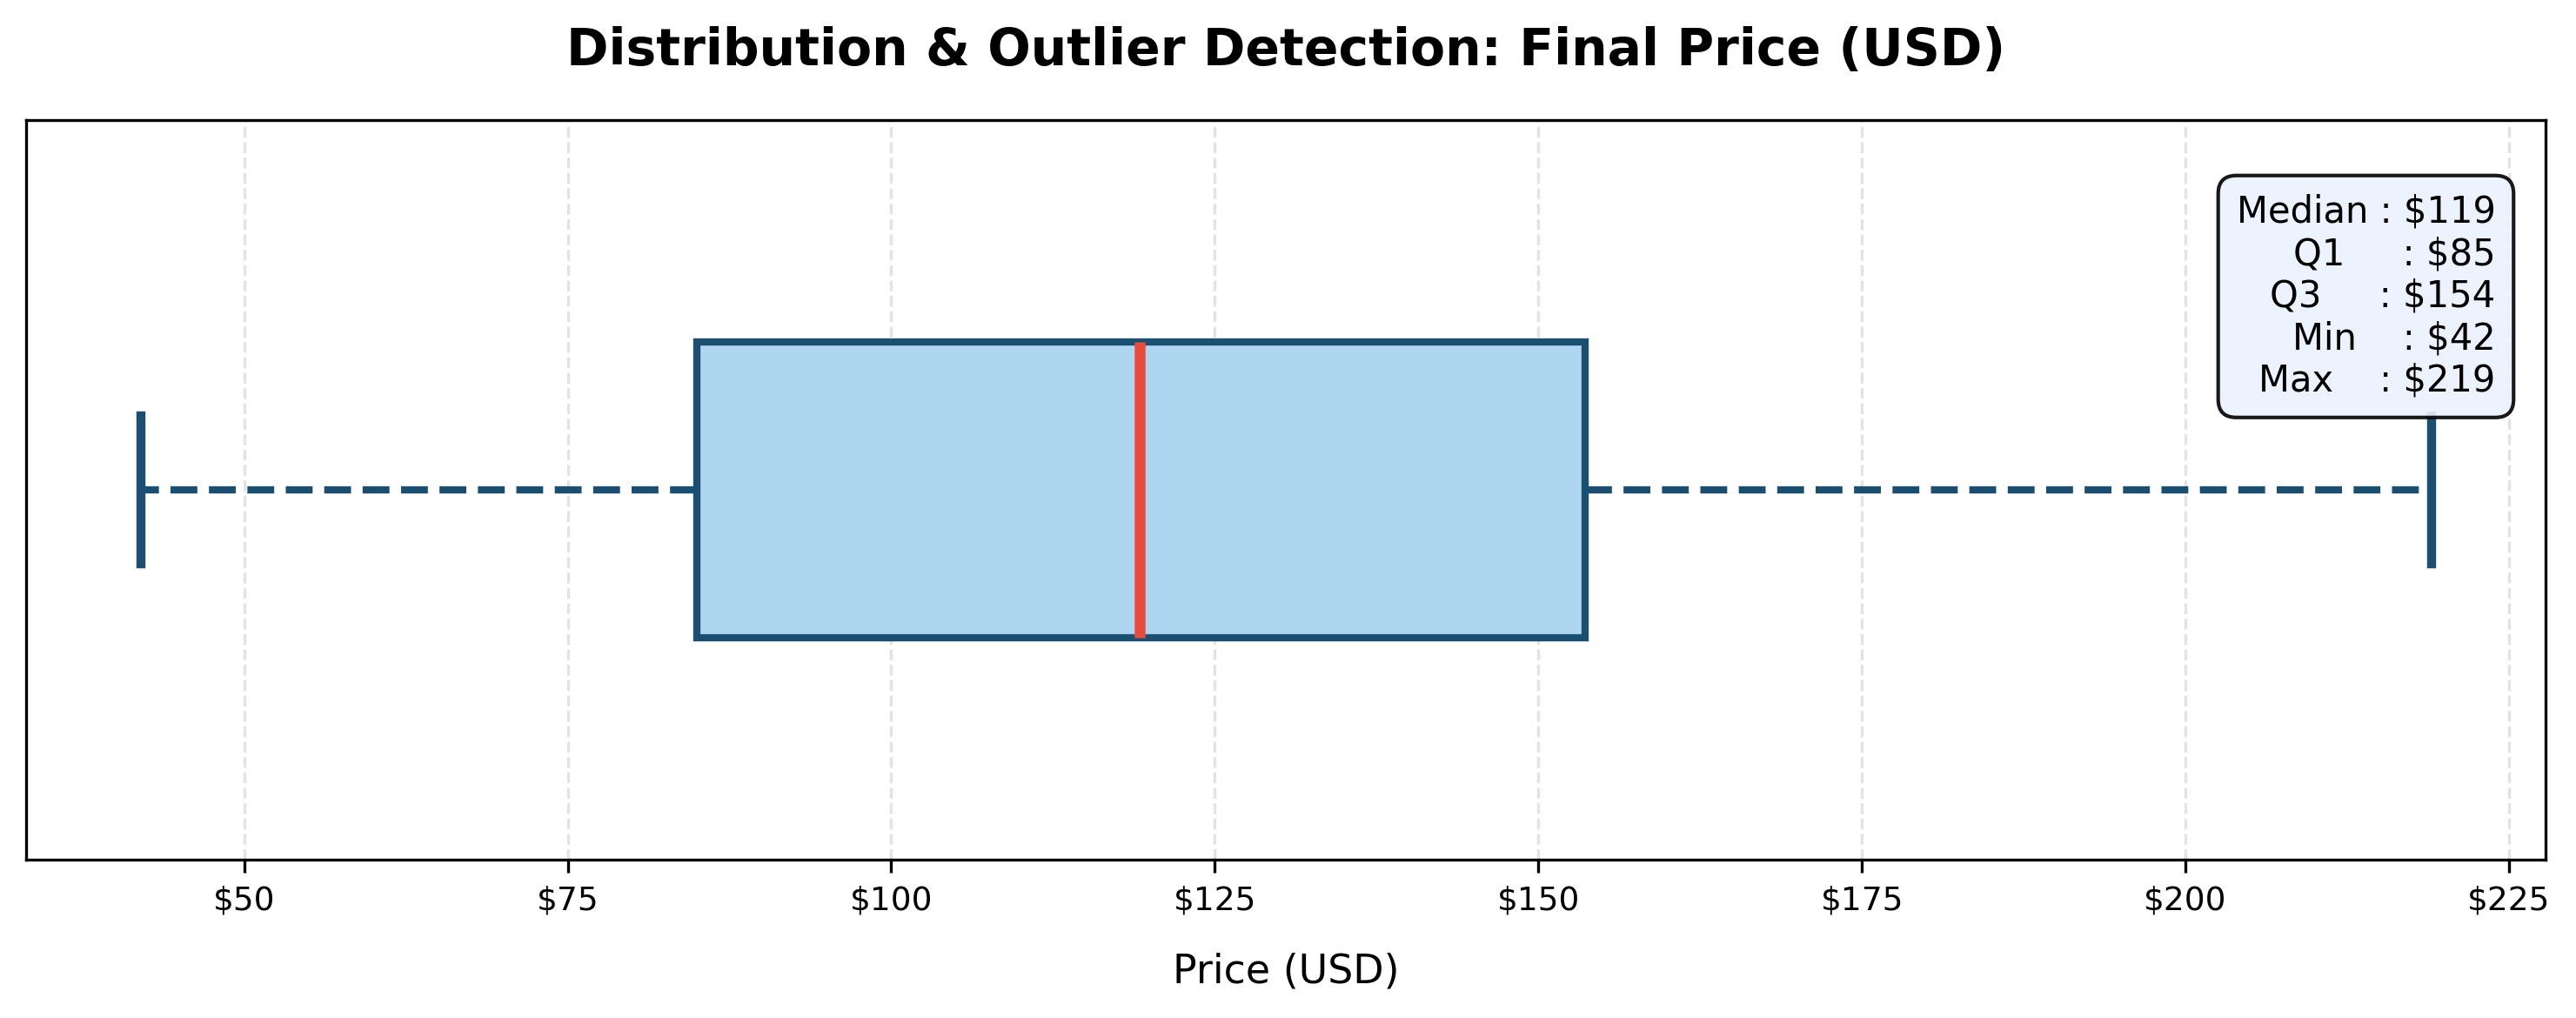

In [ ]:
# =============================================================
# EDA CLUSTERING
# Price Boxplot & Rating Histogram (outlier detection + distribution)
# =============================================================

# ---- Descriptive statistics ----
price_stats  = df['final_price_usd'].describe().round(2)
rating_stats = df['customer_rating'].describe().round(2)

# ---- Academic palette ----
COLOR_PRICE  = '#1B4F72'
COLOR_RATING = '#6C3483'
COLOR_KDE    = '#A93226'

# --- FIGURE 1: Price Boxplot (Outlier Detection) ---
fig1, ax1 = plt.subplots(figsize=(10, 4)) # Wide but not too tall
bp = ax1.boxplot(
    df['final_price_usd'].dropna(),
    vert=False,
    patch_artist=True,
    widths=0.4, # Box width
    boxprops    =dict(facecolor='#AED6F1', color=COLOR_PRICE, linewidth=2),
    medianprops =dict(color='#E74C3C', linewidth=3),
    whiskerprops=dict(color=COLOR_PRICE, linewidth=2, linestyle='--'),
    capprops    =dict(color=COLOR_PRICE, linewidth=2.5),
    flierprops  =dict(marker='o', markerfacecolor='#E74C3C',
                      alpha=0.5, markersize=5, linestyle='none', markeredgecolor='black')
)
ax1.set_title('Distribution & Outlier Detection: Final Price (USD)', fontweight='bold', fontsize=14, pad=15)
ax1.set_xlabel('Price (USD)', labelpad=10, fontsize=11)
ax1.set_yticks([])
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Statistics annotation (enlarged and repositioned)
stats_txt = (f"Median : ${price_stats['50%']:,.0f}\n"
             f"Q1     : ${price_stats['25%']:,.0f}\n"
             f"Q3     : ${price_stats['75%']:,.0f}\n"
             f"Min    : ${price_stats['min']:,.0f}\n"
             f"Max    : ${price_stats['max']:,.0f}")
ax1.text(0.98, 0.90, stats_txt, transform=ax1.transAxes,
         fontsize=10, va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#EAF2FF', edgecolor='black', alpha=0.9))

plt.tight_layout()
plt.savefig('gambar_4_X5_eda_boxplot_price.png', dpi=300, bbox_inches='tight')
plt.show()

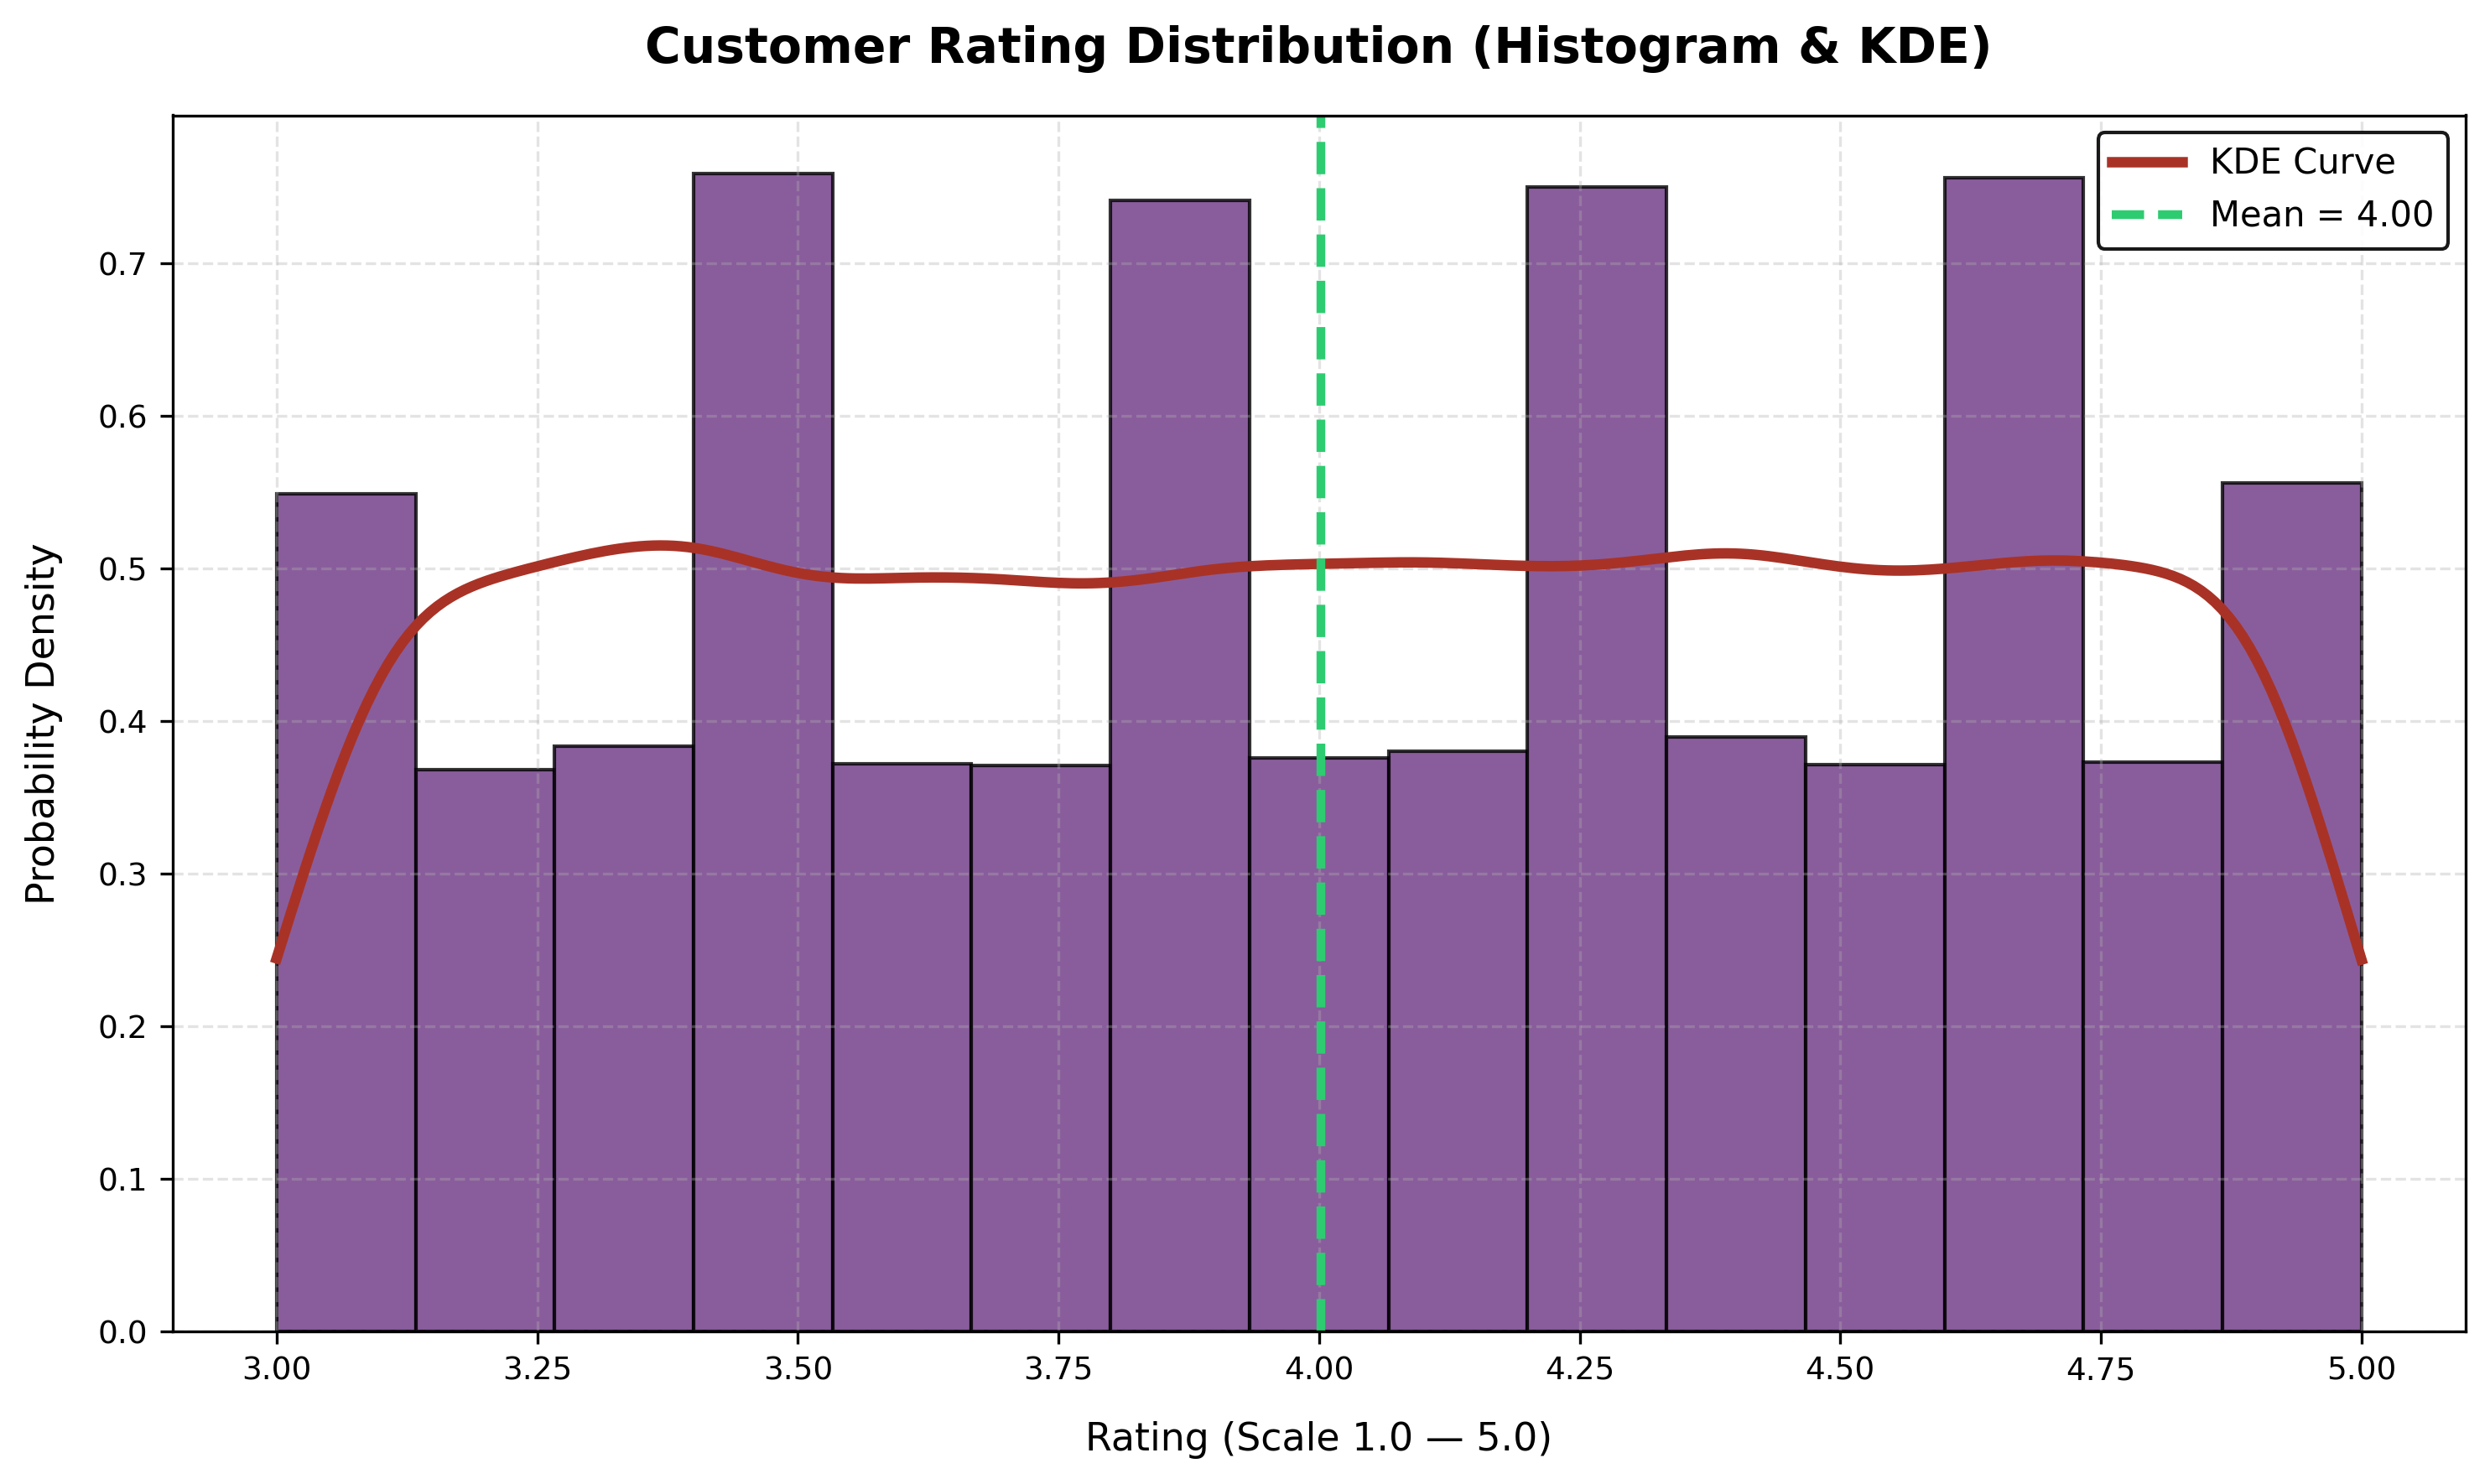


--- Descriptive Statistics: Final Price (USD) ---


,count,mean,std,min,25%,50%,75%,max
final_price_usd,30000.0,121.03,42.51,42.0,85.0,119.2,153.6,219.0



--- Descriptive Statistics: Customer Rating ---


,count,mean,std,min,25%,50%,75%,max
customer_rating,30000.0,4.0,0.58,3.0,3.5,4.0,4.5,5.0



--- Price Outlier Detection (IQR Method) ---
Q1         : $85.00  |  Q3  : $153.60
IQR        : $68.60
Lower Fence: $-17.90
Upper Fence: $256.50
Number of Outliers: 0 (0.00%)


In [ ]:
# --- FIGURE 2: Rating Histogram + KDE ---
fig2, ax2 = plt.subplots(figsize=(10, 6))
n, bins, patches = ax2.hist(
    df['customer_rating'].dropna(), bins=15,
    color=COLOR_RATING, edgecolor='black',
    linewidth=1.0, density=True, alpha=0.8
)
# KDE overlay
kde = gaussian_kde(df['customer_rating'].dropna())
x_range = np.linspace(df['customer_rating'].min(), df['customer_rating'].max(), 300)
ax2.plot(x_range, kde(x_range), color=COLOR_KDE, lw=3.0, label='KDE Curve')
ax2.axvline(df['customer_rating'].mean(), color='#2ECC71', lw=2.5,
            linestyle='--', label=f"Mean = {df['customer_rating'].mean():.2f}")

ax2.set_title('Customer Rating Distribution (Histogram & KDE)', fontweight='bold', fontsize=14, pad=15)
ax2.set_xlabel('Rating (Scale 1.0 — 5.0)', labelpad=10, fontsize=11)
ax2.set_ylabel('Probability Density', labelpad=10, fontsize=11)
ax2.legend(fontsize=10, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.savefig('gambar_4_X6_eda_hist_rating.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Statistics Summary ----
print('\n--- Descriptive Statistics: Final Price (USD) ---')
display(pd.DataFrame(price_stats).T)

print('\n--- Descriptive Statistics: Customer Rating ---')
display(pd.DataFrame(rating_stats).T)

# ---- IQR Outlier Detection ----
Q1 = df['final_price_usd'].quantile(0.25)
Q3 = df['final_price_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
n_outliers  = ((df['final_price_usd'] < lower_fence) | (df['final_price_usd'] > upper_fence)).sum()

print(f'\n--- Price Outlier Detection (IQR Method) ---')
print(f'Q1         : ${Q1:,.2f}  |  Q3  : ${Q3:,.2f}')
print(f'IQR        : ${IQR:,.2f}')
print(f'Lower Fence: ${lower_fence:,.2f}')
print(f'Upper Fence: ${upper_fence:,.2f}')
print(f'Number of Outliers: {n_outliers} ({n_outliers/len(df)*100:.2f}%)')